<a href="https://colab.research.google.com/github/Fredany07/Unpervised-Learning/blob/main/train_model_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


In [2]:
import kagglehub

# Downloads to a local cache the first time you run it
path = kagglehub.dataset_download("arjunbhasin2013/ccdata")
print("Dataset downloaded to:", path)

df = pd.read_csv(f"{path}/CC GENERAL.csv")
df.shape


Using Colab cache for faster access to the 'ccdata' dataset.
Dataset downloaded to: /kaggle/input/ccdata


(8950, 18)

In [3]:
df.head()


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [5]:
df.isnull().sum().sort_values(ascending=False).head(10)


,0
MINIMUM_PAYMENTS,313
CREDIT_LIMIT,1
BALANCE,0
CUST_ID,0
BALANCE_FREQUENCY,0
PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0


In [6]:
# Fill the two columns that have missing values with the median
df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].median())
df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].median())

df.isnull().sum().sum()  # should be 0 now


np.int64(0)

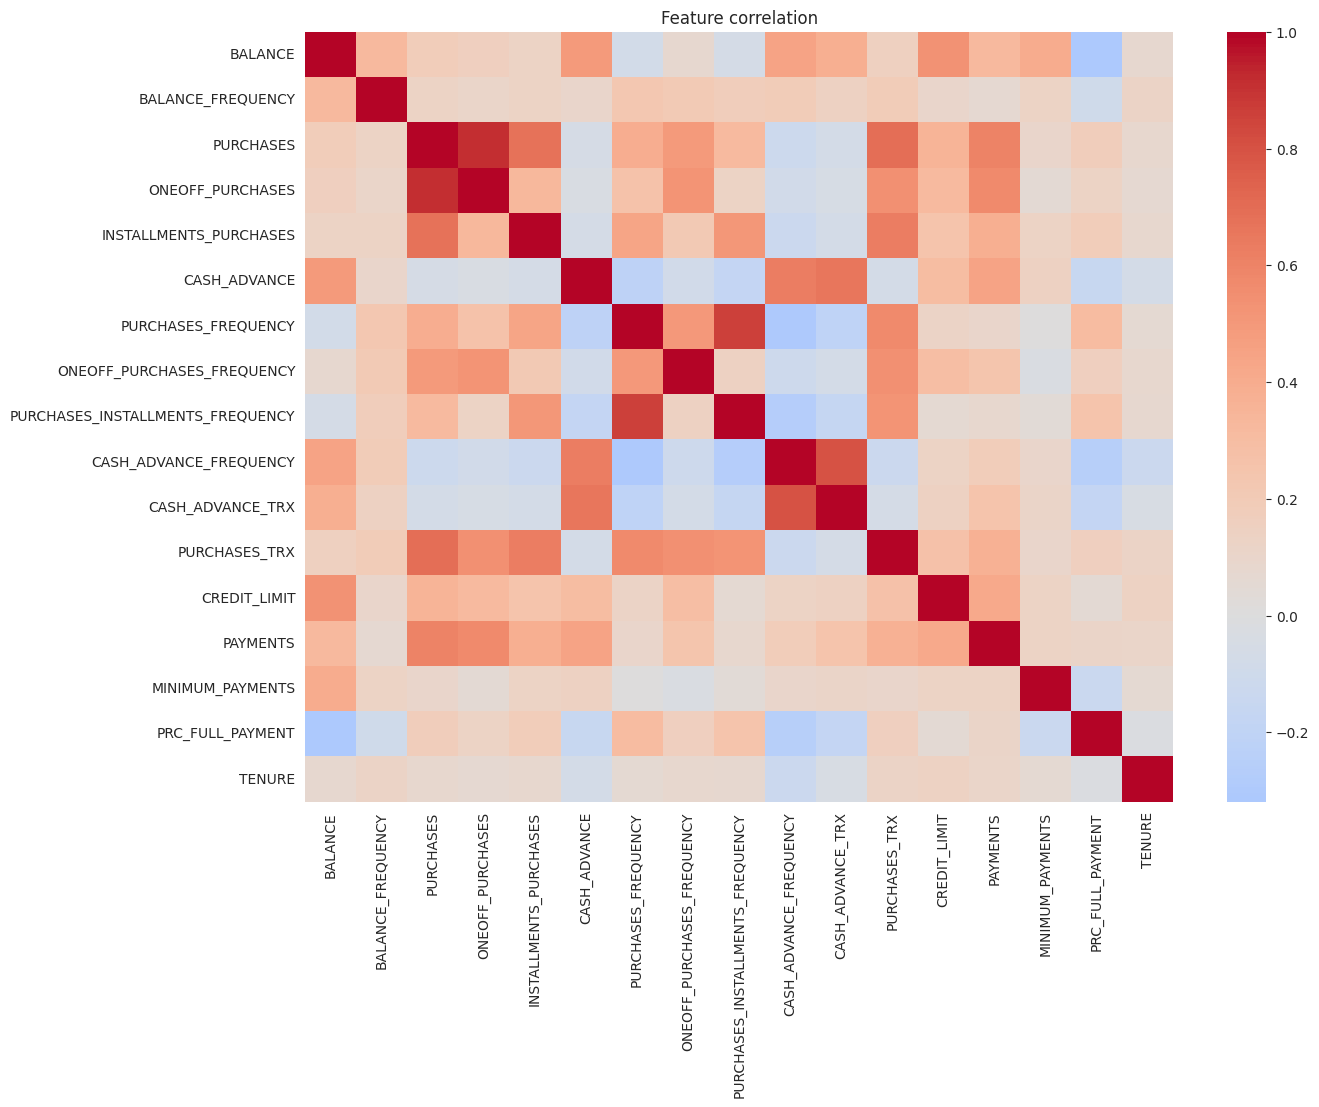

In [7]:
# Drop the customer ID -- it carries no behavioral signal
df_model = df.drop(columns=["CUST_ID"])

plt.figure(figsize=(14, 10))
sns.heatmap(df_model.corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Feature correlation")
plt.show()


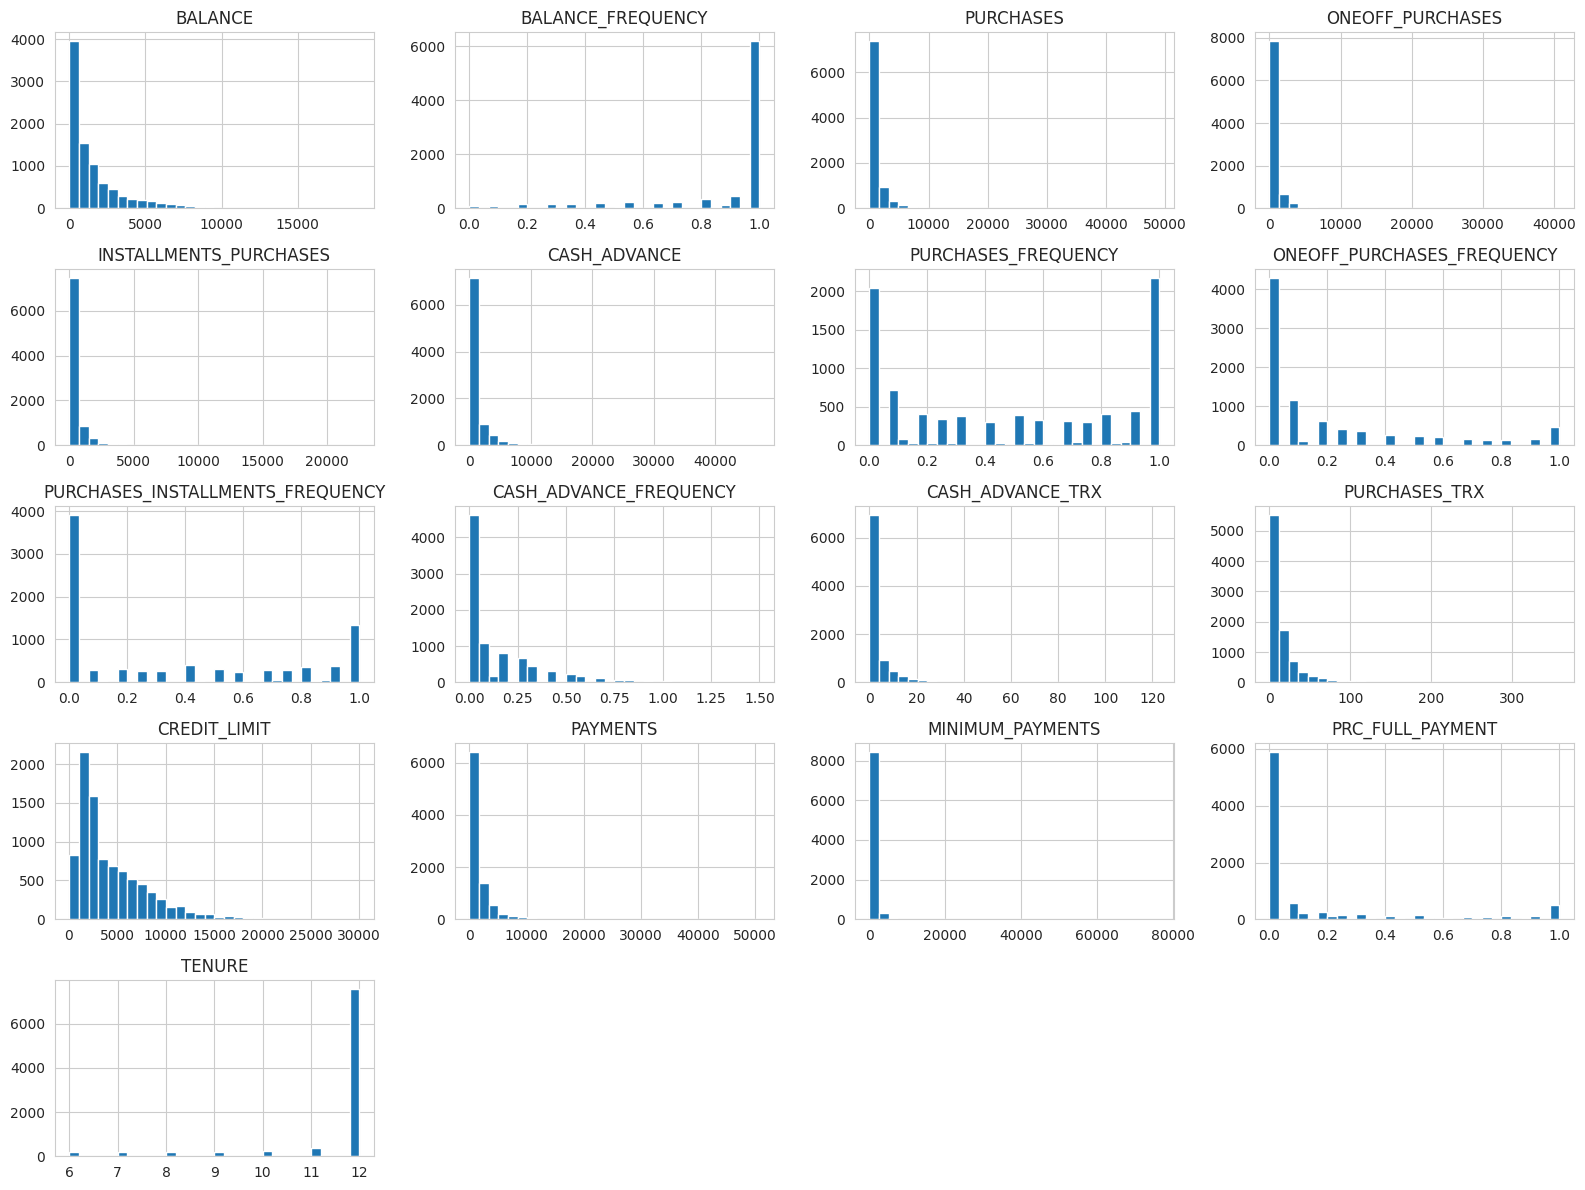

In [8]:
df_model.hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()


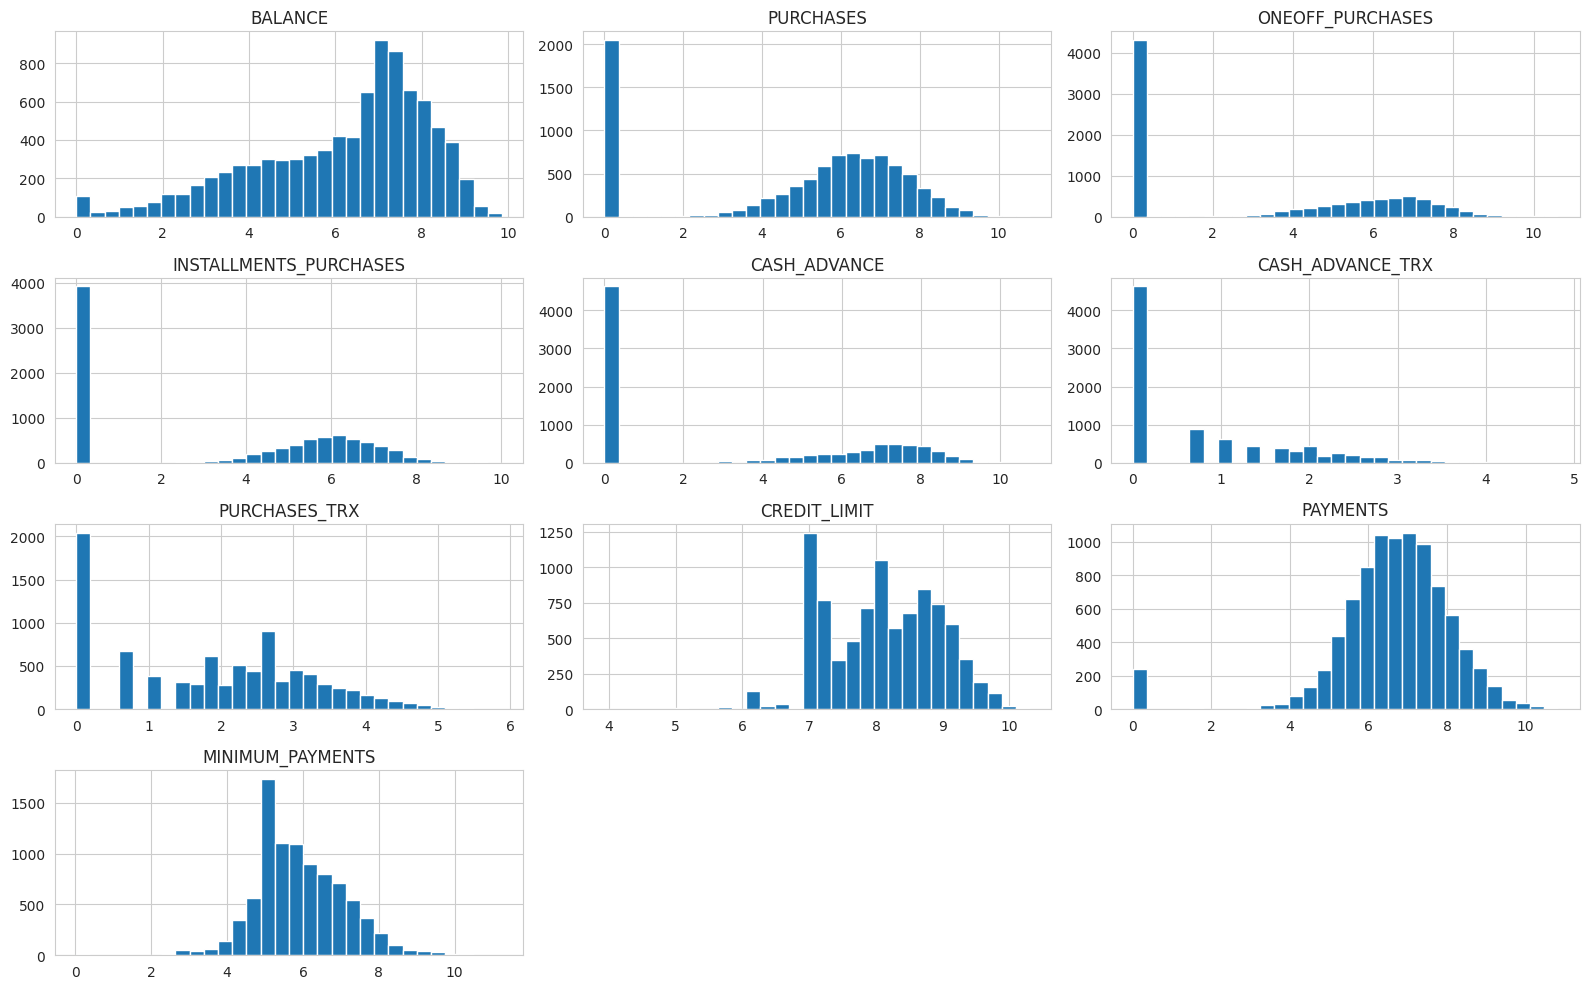

In [9]:
skewed_cols = [
    "BALANCE", "PURCHASES", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES",
    "CASH_ADVANCE", "CASH_ADVANCE_TRX", "PURCHASES_TRX", "CREDIT_LIMIT",
    "PAYMENTS", "MINIMUM_PAYMENTS"
]

df_log = df_model.copy()
for col in skewed_cols:
    df_log[col] = np.log1p(df_log[col])

df_log[skewed_cols].hist(figsize=(16, 10), bins=30)
plt.tight_layout()
plt.show()


In [10]:
feature_cols = df_log.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_log[feature_cols])
X_scaled.shape


(8950, 17)

In [11]:
pca_viz = PCA(n_components=2, random_state=42)
X_pca_viz = pca_viz.fit_transform(X_scaled)
print("Variance explained by 2 components:", pca_viz.explained_variance_ratio_.sum().round(3))


Variance explained by 2 components: 0.558


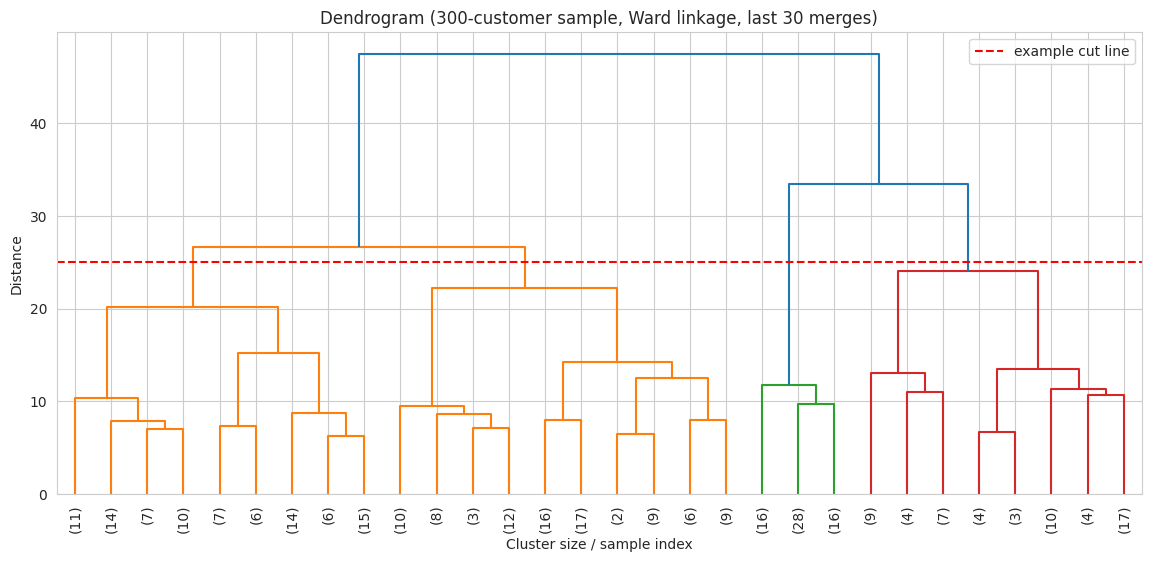

In [12]:
rng = np.random.RandomState(42)
sample_idx = rng.choice(X_scaled.shape[0], size=300, replace=False)
X_sample = X_scaled[sample_idx]

Z = linkage(X_sample, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90)
plt.title("Dendrogram (300-customer sample, Ward linkage, last 30 merges)")
plt.xlabel("Cluster size / sample index")
plt.ylabel("Distance")
plt.axhline(y=25, color="red", linestyle="--", label="example cut line")
plt.legend()
plt.show()


k=2: silhouette=0.215
k=3: silhouette=0.175
k=4: silhouette=0.166
k=5: silhouette=0.134
k=6: silhouette=0.144
k=7: silhouette=0.153


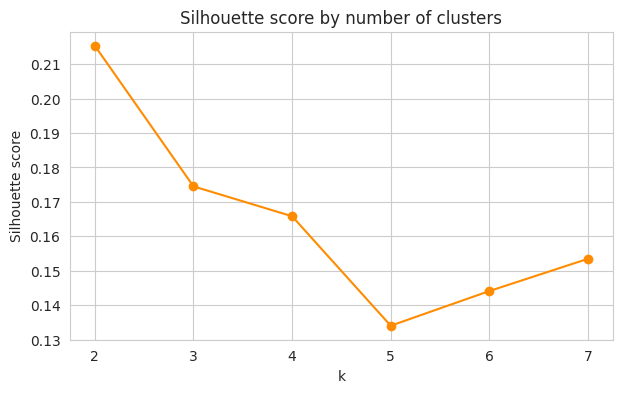

In [13]:
from sklearn.cluster import AgglomerativeClustering

sil_scores = {}
K_range = range(2, 8)

for k in K_range:
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = agg.fit_predict(X_scaled)
    sil_scores[k] = silhouette_score(X_scaled, labels)
    print(f"k={k}: silhouette={sil_scores[k]:.3f}")

plt.figure(figsize=(7, 4))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker="o", color="darkorange")
plt.title("Silhouette score by number of clusters")
plt.xlabel("k"); plt.ylabel("Silhouette score")
plt.show()


In [15]:
K_FINAL = 4

agg_clustering = AgglomerativeClustering(n_clusters=K_FINAL, linkage="ward")
cluster_labels = agg_clustering.fit_predict(X_scaled)

df_model["CLUSTER"] = cluster_labels
print("Silhouette score:", silhouette_score(X_scaled, cluster_labels).round(3))
df_model["CLUSTER"].value_counts().sort_index()


Silhouette score: 0.166


,count
CLUSTER,
0,3272
1,2255
2,1856
3,1567


In [16]:
# Centroid of each cluster in *scaled* feature space -- this is what lets us
# assign new, unseen customers to a segment later without refitting the whole tree.
cluster_centroids = pd.DataFrame(X_scaled, columns=feature_cols)
cluster_centroids["CLUSTER"] = cluster_labels
cluster_centroids = cluster_centroids.groupby("CLUSTER")[feature_cols].mean()
cluster_centroids


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
CLUSTER,,,,,,,,,,,,,,,,,
0,-0.759914,-0.501309,0.276499,-0.179082,0.194641,-0.848831,0.087201,-0.312260,0.121527,-0.637208,-0.753527,0.073535,-0.246719,-0.542623,-0.567109,0.226718,-0.055647
1,0.445980,0.097737,-1.437086,-0.830275,-0.979035,0.983294,-1.067346,-0.589384,-0.825909,0.734549,0.832493,-1.212543,-0.158543,0.053083,0.267021,-0.364614,-0.391864
2,0.685850,0.387864,0.503141,0.511598,0.229372,1.019820,0.212201,0.211849,0.141664,0.771750,0.953260,0.391691,0.266418,0.451768,0.626683,-0.392143,0.291028
3,0.132620,0.446720,0.894763,0.962795,0.730787,-0.850503,1.102551,1.249256,0.766981,-0.640608,-0.753657,1.127441,0.427764,0.521556,0.057643,0.515765,0.335406


In [17]:
plot_df = pd.DataFrame(X_pca_viz, columns=["PC1", "PC2"])
plot_df["Cluster"] = cluster_labels.astype(str)

fig = px.scatter(
    plot_df, x="PC1", y="PC2", color="Cluster",
    title="Customer clusters (PCA projection)",
    opacity=0.6
)
fig.show()


In [18]:
profile = df_model.groupby("CLUSTER")[feature_cols].mean().round(1)
profile


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
CLUSTER,,,,,,,,,,,,,,,,,
0,497.6,0.8,607.6,280.5,327.7,56.2,0.5,0.1,0.4,0.0,0.2,9.2,3602.2,816.3,356.8,0.2,11.4
1,2151.5,0.9,74.1,50.9,23.2,2007.8,0.1,0.0,0.0,0.3,6.4,1.0,3954.3,1644.7,1091.1,0.0,11.0
2,2871.5,1.0,1237.7,749.5,488.6,2153.7,0.6,0.3,0.4,0.3,7.5,19.4,5392.5,2610.9,1261.1,0.0,11.9
3,1399.4,1.0,2888.5,1837.0,1051.6,33.4,0.9,0.6,0.7,0.0,0.1,40.3,6070.2,2735.2,1017.0,0.3,12.0


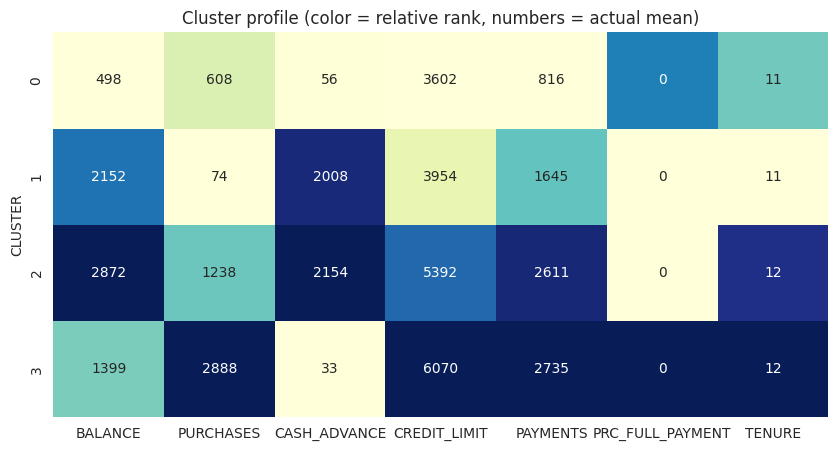

In [19]:
key_features = ["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT",
                 "PAYMENTS", "PRC_FULL_PAYMENT", "TENURE"]

norm_profile = (profile[key_features] - profile[key_features].min()) / \
               (profile[key_features].max() - profile[key_features].min())

plt.figure(figsize=(10, 5))
sns.heatmap(norm_profile, annot=profile[key_features].values, fmt=".0f",
            cmap="YlGnBu", cbar=False)
plt.title("Cluster profile (color = relative rank, numbers = actual mean)")
plt.show()


In [21]:
PERSONA_MAP = {
    0: "VIP / Premium Spender",
    1: "Low Spender",
    2: "Frequent / Loyal Spender",
    3: "High-Risk Revolver",
}

CAMPAIGN_MAP = {
    "VIP / Premium Spender": "Upgrade to premium card, raise credit limit, concierge perks",
    "Low Spender": "Cashback offers to increase card usage",
    "Frequent / Loyal Spender": "Airline miles & travel rewards program",
    "High-Risk Revolver": "Financial education content, credit counseling outreach",
}

df_model["PERSONA"] = df_model["CLUSTER"].map(PERSONA_MAP)
df_model["PERSONA"].value_counts()


,count
PERSONA,
VIP / Premium Spender,3272
Low Spender,2255
Frequent / Loyal Spender,1856
High-Risk Revolver,1567


## 8. Save the trained artifacts for the Streamlit app

In [22]:
joblib.dump(scaler, "scaler.pkl")
joblib.dump(cluster_centroids, "cluster_centroids.pkl")
joblib.dump(feature_cols, "feature_cols.pkl")
joblib.dump(skewed_cols, "skewed_cols.pkl")
joblib.dump(PERSONA_MAP, "persona_map.pkl")
joblib.dump(CAMPAIGN_MAP, "campaign_map.pkl")

print("Saved: scaler.pkl, cluster_centroids.pkl, feature_cols.pkl, skewed_cols.pkl, persona_map.pkl, campaign_map.pkl")


Saved: scaler.pkl, cluster_centroids.pkl, feature_cols.pkl, skewed_cols.pkl, persona_map.pkl, campaign_map.pkl


In [23]:
from google.colab import files

for f in ["scaler.pkl", "cluster_centroids.pkl", "feature_cols.pkl",
          "skewed_cols.pkl", "persona_map.pkl", "campaign_map.pkl"]:
    files.download(f)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9. Next steps

1. Put these `.pkl` files in the same folder as `app.py`.
2. Run the Streamlit app locally (`streamlit run app.py`) or push everything to a
   GitHub repo and deploy for free on **Streamlit Community Cloud**.
3. See `README.md` for the exact commands, including a trick for launching Streamlit
   straight from this Colab notebook if you want a live demo without leaving the browser.
